This script analyses the GloFASv5 results (KGE-JSD) in dependence of different catchment statistics.<br>

**Climate:** tp_mean_annual, tp_seasonality, eT0_mean_annual, eT0_seasonality, ta_mean, ta_seasonality, aridity_index<br>
**Terrain:** elv_mean, gradient_mean<br>
**Land use:** fracforest, fracirrigated, fracother, lusemask<br>
**Soil:** soildepth1_f, ksat1_f<br>
**Vegetation:** laii_mean, laif_mean<br>
**Glacier:** glacier_frac<br>

In [1]:
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
# import geopandas as gpd
# from shapely.geometry import Point
import glob
from scipy import stats

from tqdm import tqdm
import os
import shutil
import tempfile
import logging
import geopandas as gpd
import rioxarray as rxr

In [2]:
# LDD direction convention (PCRaster):
# 7 8 9
# 4 5 6
# 1 2 3
# For each direction, what is the (row_offset, col_offset) of the downstream neighbour?
# e.g. direction 1 means flow goes to bottom-left → downstream is at (+1, -1)

# Inverse: for each neighbour position, which LDD value points TO the current cell?
# neighbour at (-1, -1) has direction 3 if it flows to us
# neighbour at (-1,  0) has direction 2
# neighbour at (-1, +1) has direction 1
# neighbour at ( 0, -1) has direction 6
# neighbour at ( 0, +1) has direction 4
# neighbour at (+1, -1) has direction 9
# neighbour at (+1,  0) has direction 8
# neighbour at (+1, +1) has direction 7

# (row_offset, col_offset) -> LDD value that points toward current cell
UPSTREAM_DIRS = {
    (-1, -1): 3,
    (-1,  0): 2,
    (-1, +1): 1,
    ( 0, -1): 6,
    ( 0, +1): 4,
    ( 1, -1): 9,
    ( 1,  0): 8,
    ( 1, +1): 7,
}

def cutmaps_own(ldd_array, lon_array, lat_array, station_lon, station_lat):
    """
    Trace upstream from station pixel through LDD to get catchment mask.
    Returns a 2D boolean array (same shape as ldd_array).
    """
    # find nearest pixel to station coordinates
    col = np.argmin(np.abs(lon_array - station_lon))
    row = np.argmin(np.abs(lat_array - station_lat))
    # print(f"  Station pixel: row={row}, col={col}, lon={lon_array[col]:.3f}, lat={lat_array[row]:.3f}")

    nrows, ncols = ldd_array.shape
    mask = np.zeros((nrows, ncols), dtype=bool)

    # BFS upstream flood-fill
    queue = [(row, col)]
    mask[row, col] = True

    while queue:
        r, c = queue.pop()
        for (dr, dc), upstream_val in UPSTREAM_DIRS.items():
            nr, nc = r + dr, c + dc
            if 0 <= nr < nrows and 0 <= nc < ncols:
                if not mask[nr, nc] and ldd_array[nr, nc] == upstream_val:
                    mask[nr, nc] = True
                    queue.append((nr, nc))

    return mask


### Setup

In [71]:
BASE_FILE = Path.cwd () / "../glofas5_hydrobot.csv"
# Folder with static attributes
DIR_STATIC = Path("/mnt/eos_rw/projects/FLOODS-RIVER/schafti/02_GloFAS_EFAS/GloFAS/GloFASv5/static_maps/GloFASv5_staticmaps_consolidated_March2026/GloFASv5_static_maps_reanalysis/")
# Folder with parameter attributes
DIR_PARS = Path("/mnt/eos_rw/projects/FLOODS-RIVER/schafti/02_GloFAS_EFAS/GloFAS/GloFASv5/static_maps/GloFASv5_parametermaps/")

# Output Dir
DIR_OUT = Path.cwd () / "../results"

# Base File
glofas5_base_info = pd.read_csv(BASE_FILE)

In [4]:
# station list
cal_stations = glofas5_base_info[["grid_x","grid_y", "ID"]].values
if not (DIR_STATIC / "cal_stations.txt").exists():
    with open(DIR_STATIC / "cal_stations.txt", "w") as f:
        for x, y, id_ in cal_stations:
            f.write(f"{x:.3f}  {y:.3f}\t{int(id_)}\n")

In [5]:
# load GloFASv5 Parameters
glofas_pars = xr.open_mfdataset(sorted(glob.glob(str(DIR_PARS / "*.nc"))), combine="by_coords")
# glofas_pars = glofas_pars.load()

In [74]:
# Extract attributes
climate_attrs = [
    "tp_mean_annual", "tp_seasonality", "tp_std_interann",
    "eT0_mean_annual", "eT0_seasonality", "aridity_index",
    "ta_mean", "ta_seasonality"
]

terrain_attrs = [
    "elv_mean", "gradient_mean"
]

landuse_attrs = [
    "fracforest_mean", "fracirrigated_mean", "fracother_mean", "glacier_frac"
]

soil_attrs = [
    "soildepth1_f_mean", "ksat1_f_mean"
]

veg_attrs = [
    "laii_mean", "laif_mean"
]

all_attrs = climate_attrs + terrain_attrs + landuse_attrs + soil_attrs + veg_attrs

df = glofas5_base_info.copy()
kge = df["KGEmod"]


### Metric Calculation

In [ ]:
# Calculate Spearman Correlation of Attributes and KGE
spearman_results = []
for attr in all_attrs:
    valid = df[[attr, "KGEmod"]].dropna()
    if len(valid) < 10:
        continue
    r, p = stats.spearmanr(valid[attr], valid["KGEmod"])
    spearman_results.append({"attr": attr, "rho": r, "pval": p})

spearman_df = pd.DataFrame(spearman_results).sort_values("rho", key=abs, ascending=False)

/tmp/ipykernel_2314377/95400268.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.spearmanr(valid[attr], valid["KGEmod"])


In [103]:
# Partial Correlations
# If we controle for variable Z to get the Partial Correlations between A & B we:
# - Regress Z on A (Confounder = independent variable)
# - Regress Z on B 
# - Calculate Residuals from A to the Regression line of A
# - Calculate Residuals from B to the Regression line of B
# - Calculate the Correlation of the Residuals

# ─────────────────────────────────────────────
# CLIMATE DEEP DIVE — Berechnungen
# ─────────────────────────────────────────────
from scipy import stats

df_c = df.copy().reset_index(drop=True)

# ── 1. tp_mean_annual + ta_mean Partial Correlations | aridity_index ──
valid_pc = df_c[["ta_mean", "tp_mean_annual", "aridity_index", "KGEmod"]].dropna().reset_index(drop=True)

for var, name in [("ta_mean", "resid_ta"), ("tp_mean_annual", "resid_tp"), ("KGEmod", "resid_kge")]:
    slope, intercept, _, _, _ = stats.linregress(valid_pc["aridity_index"], valid_pc[var])
    valid_pc[name] = valid_pc[var] - (slope * valid_pc["aridity_index"] + intercept)

rho_ta,         pval_ta         = stats.spearmanr(valid_pc["ta_mean"],       valid_pc["KGEmod"])
rho_tp,         pval_tp         = stats.spearmanr(valid_pc["tp_mean_annual"], valid_pc["KGEmod"])
rho_ta_partial, pval_ta_partial = stats.spearmanr(valid_pc["resid_ta"],      valid_pc["resid_kge"])
rho_tp_partial, pval_tp_partial = stats.spearmanr(valid_pc["resid_tp"],      valid_pc["resid_kge"])

print(f"Raw Spearman ta_mean:                 ρ={rho_ta:.3f},  p={pval_ta:.2e}")
print(f"Partial Corr ta_mean | aridity_index: ρ={rho_ta_partial:.3f}, p={pval_ta_partial:.2e}")
print(f"\nRaw Spearman tp_mean_annual:                 ρ={rho_tp:.3f},  p={pval_tp:.2e}")
print(f"Partial Corr tp_mean_annual | aridity_index: ρ={rho_tp_partial:.3f}, p={pval_tp_partial:.2e}")

# ── 2. tp_seasonality + eT0_seasonality Partial Correlations | aridity_index ──
valid_season = df_c[["tp_seasonality", "eT0_seasonality", "aridity_index", "KGEmod"]].dropna().reset_index(drop=True)

for var, name in [("tp_seasonality", "resid_tps"), ("eT0_seasonality", "resid_et0s"), ("KGEmod", "resid_kge_s")]:
    slope, intercept, _, _, _ = stats.linregress(valid_season["aridity_index"], valid_season[var])
    valid_season[name] = valid_season[var] - (slope * valid_season["aridity_index"] + intercept)

rho_tps,         pval_tps         = stats.spearmanr(valid_season["tp_seasonality"],  valid_season["KGEmod"])
rho_et0s,        pval_et0s        = stats.spearmanr(valid_season["eT0_seasonality"], valid_season["KGEmod"])
rho_tps_partial, pval_tps_partial = stats.spearmanr(valid_season["resid_tps"],       valid_season["resid_kge_s"])
rho_et0s_partial,pval_et0s_partial= stats.spearmanr(valid_season["resid_et0s"],      valid_season["resid_kge_s"])

print(f"\nRaw Spearman tp_seasonality:                 ρ={rho_tps:.3f},  p={pval_tps:.2e}")
print(f"Partial Corr tp_seasonality | aridity_index: ρ={rho_tps_partial:.3f}, p={pval_tps_partial:.2e}")
print(f"\nRaw Spearman eT0_seasonality:                 ρ={rho_et0s:.3f},  p={pval_et0s:.2e}")
print(f"Partial Corr eT0_seasonality | aridity_index: ρ={rho_et0s_partial:.3f}, p={pval_et0s_partial:.2e}")

# ── 3. 2D Heatmap Bins: Aridity × eT0_seasonality ──
aridity_bins = [0, 1, 2, 5, 100]
aridity_labs = ["Humid (<1)", "Dry sub-humid (1-2)", "Semi-arid (2-5)", "Arid (>5)"]
season_bins  = [0, 0.25, 0.5, 0.75, 1.01]
season_labs  = ["Low (<0.25)", "Moderate (0.25-0.5)", "High (0.5-0.75)", "Very high (>0.75)"]

df_c["_aridity_bin"] = pd.cut(df_c["aridity_index"],   bins=aridity_bins, labels=aridity_labs)
df_c["_season_bin"]  = pd.cut(df_c["eT0_seasonality"], bins=season_bins,  labels=season_labs)

heatmap_kge = df_c.groupby(["_aridity_bin", "_season_bin"], observed=True)["KGEmod"].median().unstack()
heatmap_n   = df_c.groupby(["_aridity_bin", "_season_bin"], observed=True)["KGEmod"].count().unstack()

print("\n2D Heatmap KGE medians:")
print(heatmap_kge.round(3))
print("\nN per cell:")
print(heatmap_n)

Raw Spearman ta_mean:                 ρ=-0.284,  p=1.08e-100
Partial Corr ta_mean | aridity_index: ρ=-0.221, p=1.54e-60

Raw Spearman tp_mean_annual:                 ρ=0.078,  p=9.85e-09
Partial Corr tp_mean_annual | aridity_index: ρ=-0.156, p=1.69e-30

Raw Spearman tp_seasonality:                 ρ=-0.126,  p=1.59e-20
Partial Corr tp_seasonality | aridity_index: ρ=-0.021, p=1.30e-01

Raw Spearman eT0_seasonality:                 ρ=0.280,  p=1.95e-97
Partial Corr eT0_seasonality | aridity_index: ρ=0.233, p=3.87e-67

2D Heatmap KGE medians:
_season_bin          Low (<0.25)  Moderate (0.25-0.5)  High (0.5-0.75)  \
_aridity_bin                                                             
Humid (<1)                 0.749                0.662            0.784   
Dry sub-humid (1-2)        0.695                0.608            0.729   
Semi-arid (2-5)            0.578                0.528            0.659   
Arid (>5)                  0.464                0.377              NaN   

_season_b

### Plots

#### Spearman Corr - Catchment Attributes vs KGE

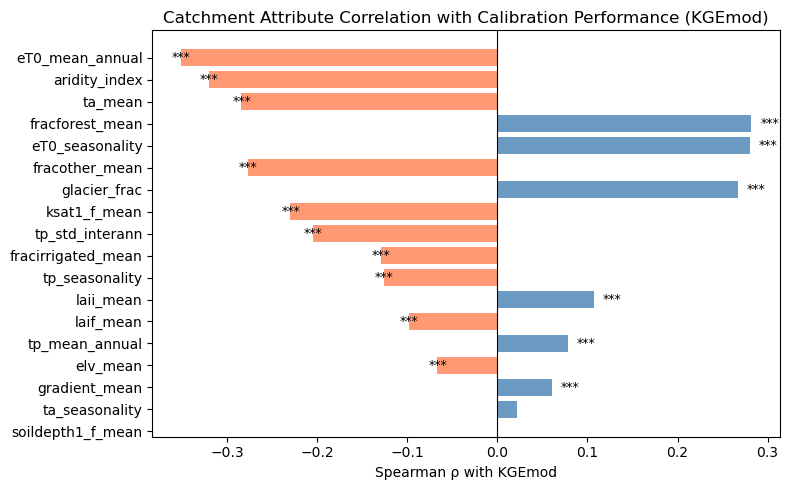

In [ ]:
# ─────────────────────────────────────────────
# PLOT 1: Spearman Korrelation Ranking
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["steelblue" if r > 0 else "coral" for r in spearman_df["rho"]]
bars = ax.barh(spearman_df["attr"], spearman_df["rho"], color=colors, alpha=0.8)

# Signifikanz markieren
for i, (_, row) in enumerate(spearman_df.iterrows()):
    marker = "***" if row.pval < 0.001 else "**" if row.pval < 0.01 else "*" if row.pval < 0.05 else ""
    if marker:
        ax.text(row.rho + 0.01 * np.sign(row.rho), i, marker, va="center", fontsize=9)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Spearman ρ with KGEmod")
ax.set_title("Catchment Attribute Correlation with Calibration Performance (KGEmod)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(DIR_OUT / "spearman_ranking.png", dpi=200, bbox_inches="tight")


#### KGE vs Aridity Classification

In [32]:
df.columns

Index(['ID', 'name', 'basin', 'river', 'provider', 'iso', 'DrainageArea_prov',
       'DrainageArea_LDD', 'lat', 'lon', 'grid_x', 'grid_y', 'SourceGlo',
       'GlofasV5', 'Obs_start', 'Obs_end', 'Split_date_CALstart', 'KGEmod',
       'JSD', 'Function', 'Region', 'elv_mean', 'elv_median', 'laii_mean',
       'laii_median', 'laif_mean', 'laif_median', 'gradient_mean',
       'gradient_median', 'lusemask_mean', 'lusemask_median',
       'soildepth1_f_mean', 'soildepth1_f_median', 'soildepth1_o_mean',
       'soildepth1_o_median', 'fracforest_mean', 'fracforest_median',
       'fracirrigated_mean', 'fracirrigated_median', 'fracother_mean',
       'fracother_median', 'ksat1_f_mean', 'ksat1_f_median', 'ksat1_o_mean',
       'ksat1_o_median', 'tp_mean_annual', 'tp_std_interann', 'tp_seasonality',
       'eT0_mean_annual', 'eT0_std_interann', 'eT0_seasonality', 'ta_mean',
       'ta_std_interann', 'ta_seasonality', 'aridity_index',
       'param_CalChanMan1', 'param_CalChanMan3', 'param_GwLo

/tmp/ipykernel_2314377/3295796028.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, labels=aridity_order, patch_artist=True, notch=True,


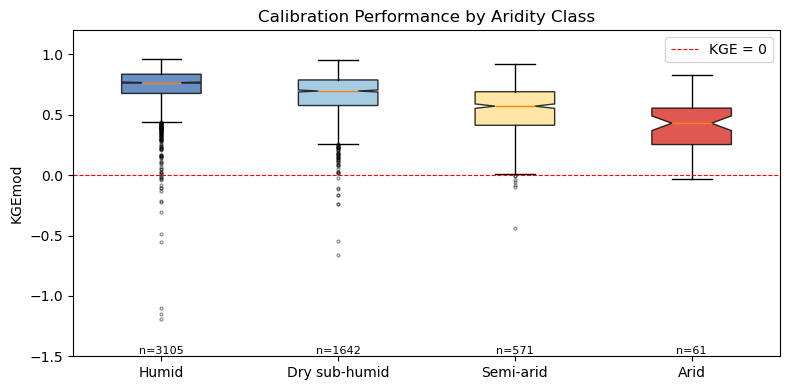

In [28]:
# Aridity-Klassen nach UNEP Definition
def aridity_class(ai):
    """Budyko-style aridity index: ai = PET/P
    ai < 1    → Humid
    1-2       → Dry sub-humid
    2-5       → Semi-arid
    5-20      → Arid
    >20       → Hyper-arid
    """
    if ai < 1.0:    return "Humid"
    elif ai < 2.0:  return "Dry sub-humid"
    elif ai < 5.0:  return "Semi-arid"
    elif ai < 120.0: return "Arid"
    # else:           return "Hyper-arid"

# aridity_order = ["Humid", "Dry sub-humid", "Semi-arid", "Arid", "Hyper-arid"]
aridity_order = ["Humid", "Dry sub-humid", "Semi-arid", "Arid"]
df["aridity_class"] = df["aridity_index"].apply(aridity_class)

fig, ax = plt.subplots(figsize=(8, 4))
data_by_class = [df[df.aridity_class == c]["KGEmod"].dropna().values for c in aridity_order]
bp = ax.boxplot(data_by_class, labels=aridity_order, patch_artist=True, notch=True,
                flierprops=dict(marker="o", markersize=2, alpha=0.4, linestyle="none"))
# colors_box = ["#d73027", "#fc8d59", "#fee090", "#91bfdb", "#4575b4"]
colors_box = ["#d73027", "#fee090", "#91bfdb", "#4575b4"]
colors_box = colors_box[::-1]
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_ylim(-1.5,1.2)

# N pro Klasse
for i, (cls, d) in enumerate(zip(aridity_order, data_by_class)):
    ax.text(i+1, ax.get_ylim()[0] + 0.02, f"n={len(d)}", ha="center", fontsize=8)

ax.axhline(0, color="red", linestyle="--", linewidth=0.8, label="KGE = 0")
ax.set_ylabel("KGEmod")
ax.set_title("Calibration Performance by Aridity Class")
ax.legend()

plt.tight_layout()
plt.savefig(DIR_OUT / "kge_by_aridity.png", dpi=200, bbox_inches="tight")

#### KGE vs Glacier Fraction

/tmp/ipykernel_2314377/748990722.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_glacier, labels=glacier_labels, patch_artist=True, notch=True,


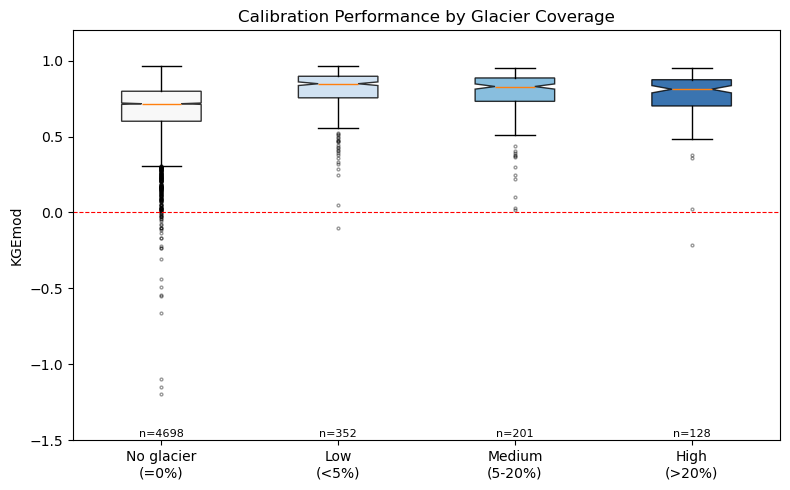

In [38]:
# ─────────────────────────────────────────────
# PLOT 3: KGE nach Glacier Fraction Bins
# ─────────────────────────────────────────────

glacier_bins  = [-0.001, 0.001, 0.05, 0.2, 1.01]
glacier_labels = ["No glacier\n(=0%)", "Low\n(<5%)", "Medium\n(5-20%)", "High\n(>20%)"]
df["glacier_class"] = pd.cut(df["glacier_frac"], bins=glacier_bins, labels=glacier_labels)

fig, ax = plt.subplots(figsize=(8, 5))
data_by_glacier = [df[df.glacier_class == c]["KGEmod"].dropna().values for c in glacier_labels]
bp = ax.boxplot(data_by_glacier, labels=glacier_labels, patch_artist=True, notch=True,
                flierprops=dict(marker="o", markersize=2, alpha=0.4, linestyle="none"))
glacier_colors = ["#f7f7f7", "#c6dbef", "#6baed6", "#08519c"]
ax.set_ylim(-1.5,1.2)

for patch, color in zip(bp["boxes"], glacier_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

for i, (cls, d) in enumerate(zip(glacier_labels, data_by_glacier)):
    ax.text(i+1, ax.get_ylim()[0] + 0.02, f"n={len(d)}", ha="center", fontsize=8)

ax.axhline(0, color="red", linestyle="--", linewidth=0.8)
ax.set_ylabel("KGEmod")
ax.set_title("Calibration Performance by Glacier Coverage")
plt.tight_layout()
plt.savefig(DIR_OUT / "kge_by_glacier.png", dpi=200, bbox_inches="tight")

In [48]:
df.columns

Index(['ID', 'name', 'basin', 'river', 'provider', 'iso', 'DrainageArea_prov',
       'DrainageArea_LDD', 'lat', 'lon', 'grid_x', 'grid_y', 'SourceGlo',
       'GlofasV5', 'Obs_start', 'Obs_end', 'Split_date_CALstart', 'KGEmod',
       'JSD', 'Function', 'Region', 'elv_mean', 'elv_median', 'laii_mean',
       'laii_median', 'laif_mean', 'laif_median', 'gradient_mean',
       'gradient_median', 'lusemask_mean', 'lusemask_median',
       'soildepth1_f_mean', 'soildepth1_f_median', 'soildepth1_o_mean',
       'soildepth1_o_median', 'fracforest_mean', 'fracforest_median',
       'fracirrigated_mean', 'fracirrigated_median', 'fracother_mean',
       'fracother_median', 'ksat1_f_mean', 'ksat1_f_median', 'ksat1_o_mean',
       'ksat1_o_median', 'tp_mean_annual', 'tp_std_interann', 'tp_seasonality',
       'eT0_mean_annual', 'eT0_std_interann', 'eT0_seasonality', 'ta_mean',
       'ta_std_interann', 'ta_seasonality', 'aridity_index',
       'param_CalChanMan1', 'param_CalChanMan3', 'param_GwLo

In [54]:
print(top_attrs)

['eT0_mean_annual', 'aridity_index', 'ta_mean', 'fracforest_mean', 'eT0_seasonality', 'fracother_mean', 'glacier_frac', 'ksat1_f_mean']


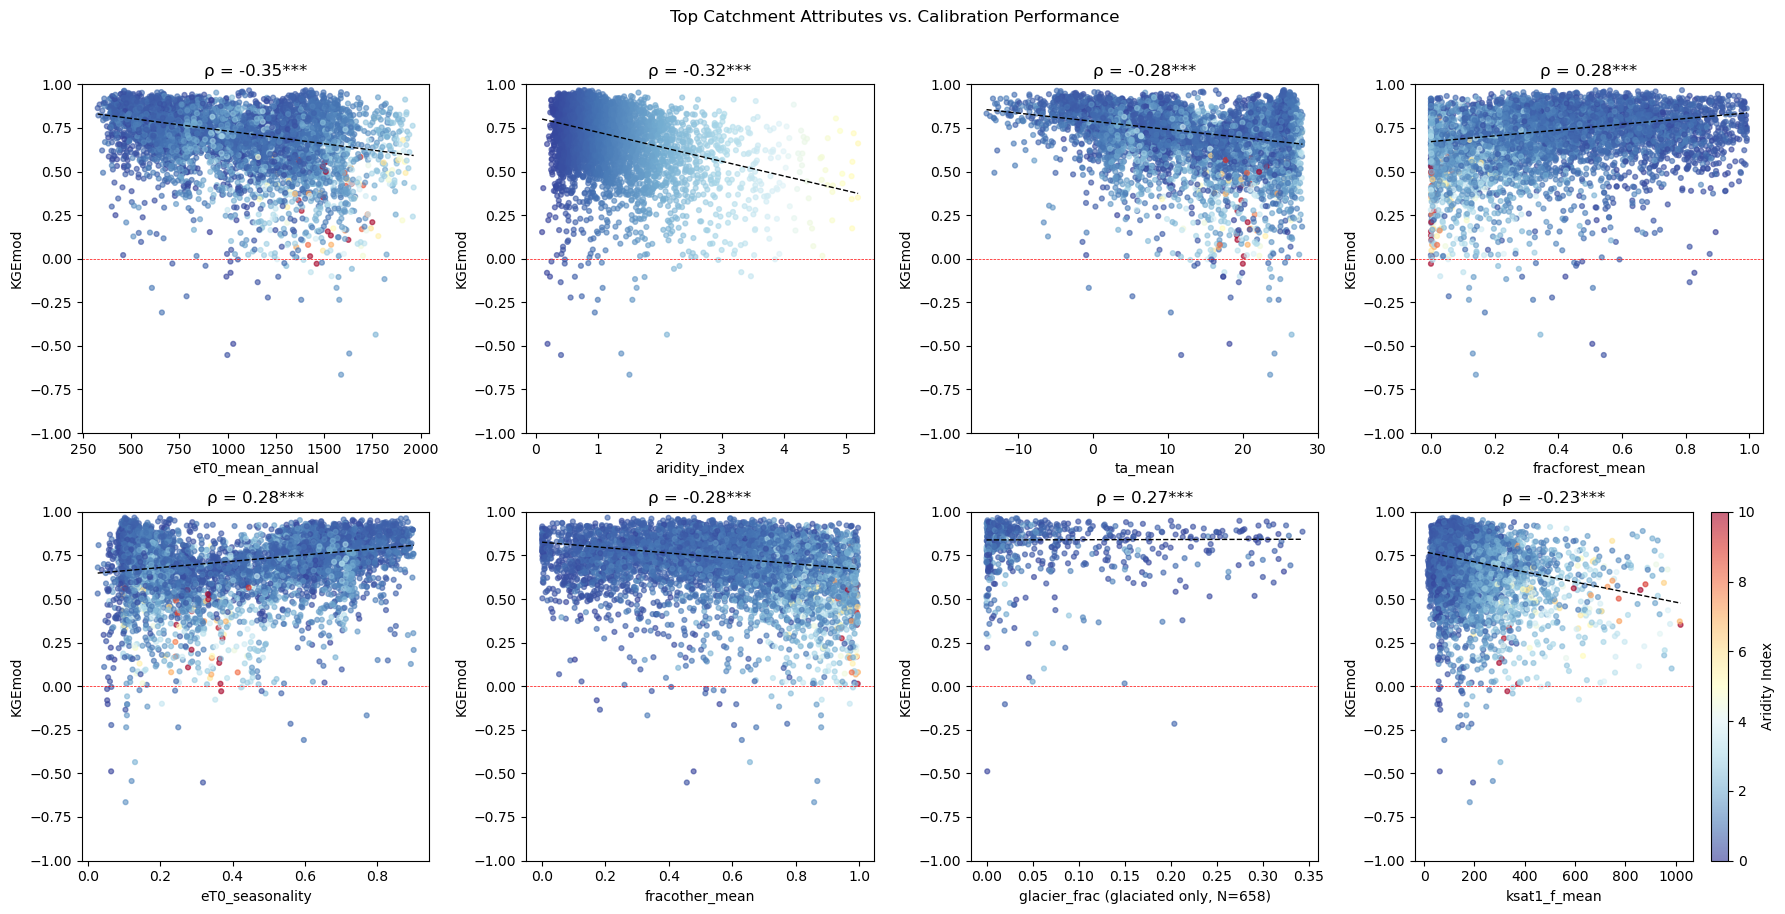

In [61]:
# ─────────────────────────────────────────────
# PLOT 4: Scatter Matrix — Top Attribute vs KGE
# ─────────────────────────────────────────────
from scipy.stats import mstats

# Top 6 nach Spearman rho (absolut)
top_attrs = spearman_df.head(8)["attr"].tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, attr in enumerate(top_attrs):
    ax = axes[i]
    cols = [attr, "KGEmod"] if attr == "aridity_index" else [attr, "KGEmod", "aridity_index"]
    valid = df[cols].dropna().reset_index(drop=True)
    
    x_clip = valid[attr].quantile(0.99)
    plot_data = valid[valid[attr] <= x_clip].copy()
      # Nur Stationen mit Vergletscherung für glacier_frac
    if attr == "glacier_frac":
        plot_data = plot_data[plot_data[attr] > 0].copy()
    if attr == "glacier_frac":
        plot_data = plot_data[plot_data[attr] > 0].copy()
        xlabel = f"glacier_frac (glaciated only, N={len(plot_data)})"
    else:
        xlabel = attr
    sc = ax.scatter(plot_data[attr], plot_data["KGEmod"],
                    c=plot_data["aridity_index"] if "aridity_index" in plot_data.columns else plot_data[attr],
                    cmap="RdYlBu_r", alpha=0.6, s=12, vmin=0, vmax=10)
    
    res = stats.theilslopes(plot_data["KGEmod"], plot_data[attr])
    x_line = np.linspace(plot_data[attr].min(), plot_data[attr].max(), 100)
    ax.plot(x_line, res.slope * x_line + res.intercept, "k--", linewidth=1)
    ax.set_ylim(-1, 1)
    
    rho = spearman_df[spearman_df.attr == attr]["rho"].values[0]
    pval = spearman_df[spearman_df.attr == attr]["pval"].values[0]
    pstar = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
    ax.set_xlabel(xlabel)
    ax.set_ylabel("KGEmod")
    ax.set_title(f"ρ = {rho:.2f}{pstar}")
    ax.axhline(0, color="red", linestyle="--", linewidth=0.5)

plt.colorbar(sc, ax=axes[-1], label="Aridity Index")
plt.suptitle("Top Catchment Attributes vs. Calibration Performance", y=1.01)
plt.tight_layout()
plt.savefig(DIR_OUT / "scatter_top_attrs.png", dpi=200, bbox_inches="tight")

#### World Map

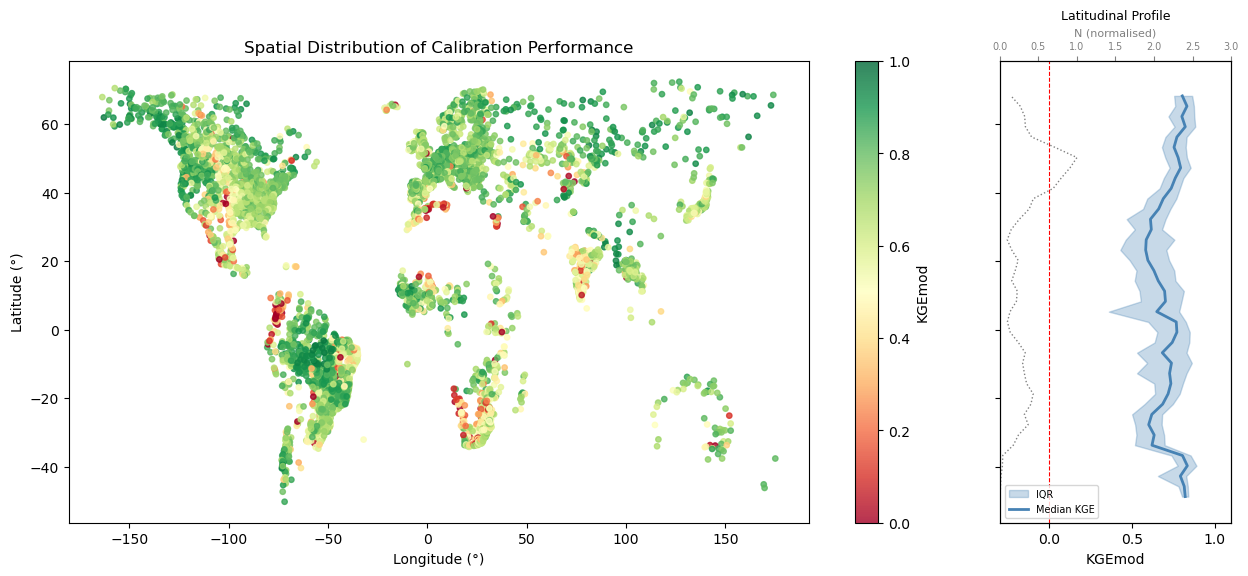

In [ ]:
# import matplotlib.gridspec as gridspec

# fig = plt.figure(figsize=(15, 6))
# gs  = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.01)

# # ── Weltkarte ──
# ax_map = fig.add_subplot(gs[0])
# sc = ax_map.scatter(df["lon"], df["lat"],
#                     c=df["KGEmod"], cmap="RdYlGn",
#                     s=15, vmin=0, vmax=1, alpha=0.8)
# plt.colorbar(sc, ax=ax_map, label="KGEmod", shrink=1)
# ax_map.set_xlabel("Longitude (°)")
# ax_map.set_ylabel("Latitude (°)")
# ax_map.set_title("Spatial Distribution of Calibration Performance")

# # ── Latitude Profil ──
# ax_lat = fig.add_subplot(gs[1], sharey=ax_map)

# # Latitude Bins
# lat_bins  = np.arange(df.lat.min(), df.lat.max(), 3)  # 5° Bänder
# lat_mids  = (lat_bins[:-1] + lat_bins[1:]) / 2

# kge_median = []
# kge_q25    = []
# kge_q75    = []
# n_per_band = []

# for lo, hi in zip(lat_bins[:-1], lat_bins[1:]):
#     band = df[(df["lat"] >= lo) & (df["lat"] < hi)]["KGEmod"].dropna()
#     kge_median.append(band.median() if len(band) > 0 else np.nan)
#     kge_q25.append(band.quantile(0.25) if len(band) > 0 else np.nan)
#     kge_q75.append(band.quantile(0.75) if len(band) > 0 else np.nan)
#     n_per_band.append(len(band))

# kge_median = np.array(kge_median)
# kge_q25    = np.array(kge_q25)
# kge_q75    = np.array(kge_q75)
# n_per_band = np.array(n_per_band, dtype=float)

# # KGE Medianlinie + IQR
# ax_lat.fill_betweenx(lat_mids, kge_q25, kge_q75,
#                      alpha=0.3, color="steelblue", label="IQR")
# ax_lat.plot(kge_median, lat_mids,
#             color="steelblue", linewidth=2, label="Median KGE")
# ax_lat.axvline(0, color="red", linestyle="--", linewidth=0.8)

# # N als zweite x-Achse
# ax_n = ax_lat.twiny()
# n_norm = n_per_band / n_per_band.max()  # normiert auf 0-1
# ax_n.plot(n_norm, lat_mids,
#           color="gray", linewidth=1, linestyle=":", label="N (normalised)")
# ax_n.set_xlim(0, 3)  # N nach links drücken damit es nicht überlappt
# ax_n.set_xlabel("N (normalised)", color="gray", fontsize=8)
# ax_n.tick_params(axis="x", colors="gray", labelsize=7)

# ax_lat.set_xlabel("KGEmod")
# ax_lat.set_xlim(-0.3, 1.1)
# ax_lat.tick_params(labelleft=False)  # Y-Labels von Karte übernommen
# ax_lat.set_title("Latitudinal Profile", fontsize=9)
# ax_lat.legend(fontsize=7, loc="lower left")

# plt.savefig(DIR_OUT / "kge_spatial_latitude_profile.png", dpi=200, bbox_inches="tight")


/storage/schafti/conda/schafti_env/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


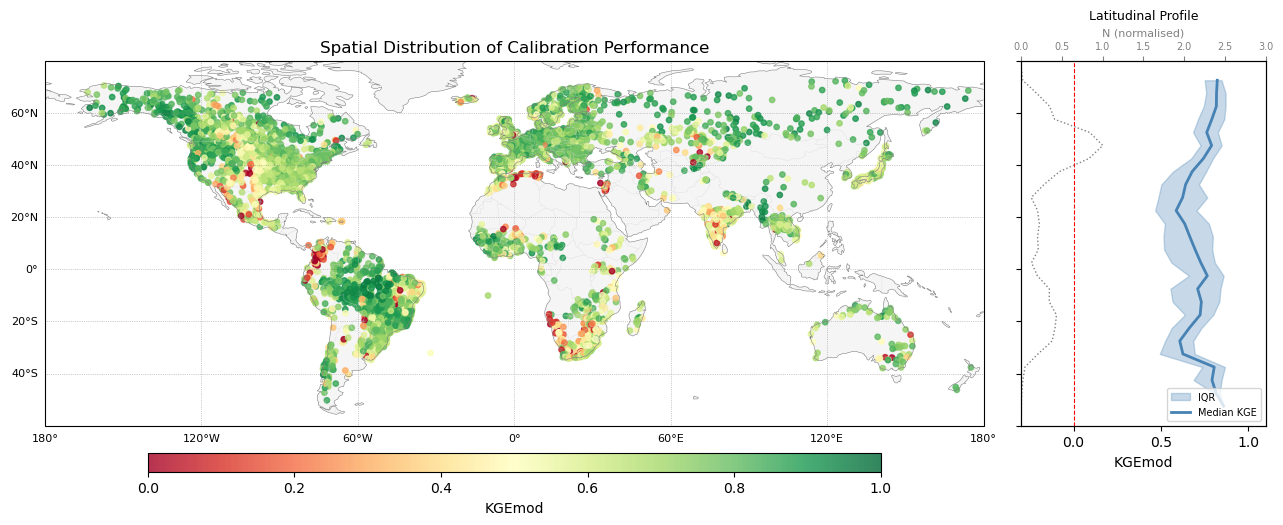

In [97]:
import cartopy.mpl.ticker as cticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.03)

# ── Weltkarte ──
ax_map = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())
ax_map.set_extent([-180, 180, -60, 80], crs=ccrs.PlateCarree())
ax_map.add_feature(cfeature.COASTLINE, linewidth=0.4, color="gray")
ax_map.add_feature(cfeature.BORDERS,   linewidth=0.2, color="lightgray")
ax_map.add_feature(cfeature.LAND,      facecolor="whitesmoke")
# ax_map.add_feature(cfeature.OCEAN,     facecolor="aliceblue")

gl = ax_map.gridlines(draw_labels=True, linewidth=0.5, color="gray",
                      alpha=0.75, linestyle=":",zorder=0)
gl.top_labels   = False
gl.right_labels = False
gl.xformatter = cticker.LongitudeFormatter()
gl.yformatter = cticker.LatitudeFormatter()
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}

sc = ax_map.scatter(df["lon"], df["lat"],
                    c=df["KGEmod"], cmap="RdYlGn",
                    s=15, vmin=0, vmax=1, alpha=0.8,
                    transform=ccrs.PlateCarree())

cbar = plt.colorbar(sc, ax=ax_map, orientation="horizontal",
                    pad=0.06, shrink=0.75, aspect=40, label="KGEmod")
ax_map.set_title("Spatial Distribution of Calibration Performance")

# ── Latitude Bins berechnen ──
lat_bins  = np.arange(-60, 81, 5)
lat_mids  = (lat_bins[:-1] + lat_bins[1:]) / 2

kge_median = []
kge_q25    = []
kge_q75    = []
n_per_band = []

for lo, hi in zip(lat_bins[:-1], lat_bins[1:]):
    band = df[(df["lat"] >= lo) & (df["lat"] < hi)]["KGEmod"].dropna()
    kge_median.append(band.median() if len(band) > 0 else np.nan)
    kge_q25.append(band.quantile(0.25) if len(band) > 0 else np.nan)
    kge_q75.append(band.quantile(0.75) if len(band) > 0 else np.nan)
    n_per_band.append(len(band))

kge_median = np.array(kge_median)
kge_q25    = np.array(kge_q25)
kge_q75    = np.array(kge_q75)
n_per_band = np.array(n_per_band, dtype=float)

# ── Latitude Profil ──
ax_lat = fig.add_subplot(gs[1])
ax_lat.set_ylim(-60, 80)

ax_lat.fill_betweenx(lat_mids, kge_q25, kge_q75,
                     alpha=0.3, color="steelblue", label="IQR")
ax_lat.plot(kge_median, lat_mids,
            color="steelblue", linewidth=2, label="Median KGE")
ax_lat.axvline(0, color="red", linestyle="--", linewidth=0.8)

ax_n = ax_lat.twiny()
n_norm = n_per_band / n_per_band.max()
ax_n.plot(n_norm, lat_mids,
          color="gray", linewidth=1, linestyle=":", label="N (normalised)")
ax_n.set_xlim(0, 3)
ax_n.set_xlabel("N (normalised)", color="gray", fontsize=8)
ax_n.tick_params(axis="x", colors="gray", labelsize=7)

ax_lat.set_xlabel("KGEmod")
ax_lat.set_xlim(-0.3, 1.1)
ax_lat.tick_params(labelleft=False)
ax_lat.set_title("Latitudinal Profile", fontsize=9)
ax_lat.legend(fontsize=7, loc="lower right")

# ── Latitude Achsen angleichen ──
plt.draw()
pos_map = ax_map.get_position()
pos_lat = ax_lat.get_position()
ax_lat.set_position([pos_lat.x0, pos_map.y0, pos_lat.width, pos_map.height])

plt.savefig(DIR_OUT / "kge_spatial_latitude_profile.png", dpi=300, bbox_inches="tight")


#### Deep Dive Climate Plot

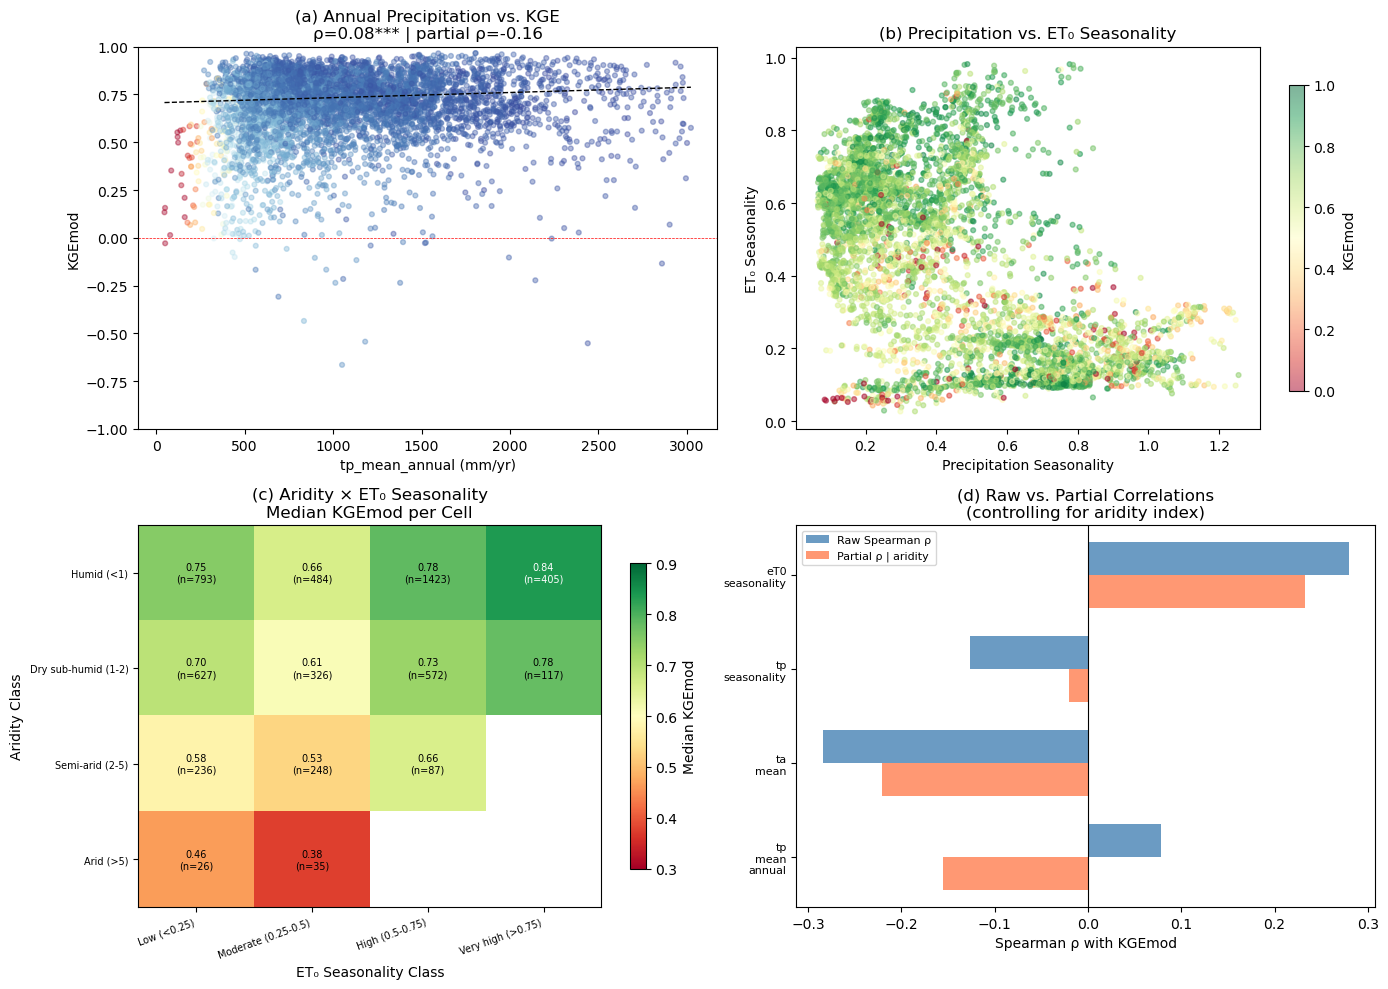

In [108]:
# ─────────────────────────────────────────────
# CLIMATE DEEP DIVE — Plots
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# ── Plot 1: tp_mean_annual vs KGE ──
ax = axes[0]
valid = df_c[["tp_mean_annual", "KGEmod", "aridity_index"]].dropna().reset_index(drop=True)
x_clip = valid["tp_mean_annual"].quantile(0.99)
plot_data = valid[valid["tp_mean_annual"] <= x_clip]
sc = ax.scatter(plot_data["tp_mean_annual"], plot_data["KGEmod"],
                c=plot_data["aridity_index"], cmap="RdYlBu_r",
                alpha=0.4, s=12, vmin=0, vmax=10)
res = stats.theilslopes(plot_data["KGEmod"], plot_data["tp_mean_annual"])
x_line = np.linspace(plot_data["tp_mean_annual"].min(), plot_data["tp_mean_annual"].max(), 100)
ax.plot(x_line, res.slope * x_line + res.intercept, "k--", linewidth=1)
ax.axhline(0, color="red", linestyle="--", linewidth=0.5)
ax.set_xlabel("tp_mean_annual (mm/yr)")
ax.set_ylabel("KGEmod")
pstar = "***" if pval_tp < 0.001 else "**" if pval_tp < 0.01 else "*"
ax.set_title(f"(a) Annual Precipitation vs. KGE\nρ={rho_tp:.2f}{pstar} | partial ρ={rho_tp_partial:.2f}")
ax.set_ylim(-1, 1)

# ── Plot 2: tp_seasonality vs eT0_seasonality, eingefärbt nach KGE ──
ax = axes[1]
valid = df_c[["tp_seasonality", "eT0_seasonality", "KGEmod"]].dropna().reset_index(drop=True)
sc2 = ax.scatter(valid["tp_seasonality"], valid["eT0_seasonality"],
                 c=valid["KGEmod"], cmap="RdYlGn",
                 alpha=0.5, s=12, vmin=0, vmax=1)
plt.colorbar(sc2, ax=ax, label="KGEmod", shrink=0.8)
ax.set_xlabel("Precipitation Seasonality")
ax.set_ylabel("ET₀ Seasonality")
ax.set_title("(b) Precipitation vs. ET₀ Seasonality")

# ── Plot 3: 2D Heatmap Aridity × eT0_seasonality ──
ax = axes[2]
im = ax.imshow(heatmap_kge.values, cmap="RdYlGn", vmin=0.3, vmax=0.9,
               aspect="auto", origin="upper")
plt.colorbar(im, ax=ax, label="Median KGEmod", shrink=0.8)

# N als Annotation
for i in range(heatmap_kge.shape[0]):
    for j in range(heatmap_kge.shape[1]):
        kge_val = heatmap_kge.values[i, j]
        n_val   = heatmap_n.values[i, j]
        if not np.isnan(kge_val):
            ax.text(j, i, f"{kge_val:.2f}\n(n={int(n_val)})",
                    ha="center", va="center", fontsize=7,
                    color="black" if 0.3 < kge_val < 0.8 else "white")

ax.set_xticks(range(len(heatmap_kge.columns)))
ax.set_xticklabels(heatmap_kge.columns, fontsize=7, rotation=20, ha="right")
ax.set_yticks(range(len(heatmap_kge.index)))
ax.set_yticklabels(heatmap_kge.index, fontsize=7)
ax.set_xlabel("ET₀ Seasonality Class")
ax.set_ylabel("Aridity Class")
ax.set_title("(c) Aridity × ET₀ Seasonality\nMedian KGEmod per Cell")

# ── Plot 4: Partial Correlation Summary Barplot ──
ax = axes[3]
attrs    = ["tp_mean_annual", "ta_mean", "tp_seasonality", "eT0_seasonality"]
rho_raw  = [rho_tp,         rho_ta,         rho_tps,         rho_et0s]
rho_part = [rho_tp_partial, rho_ta_partial, rho_tps_partial, rho_et0s_partial]

x     = np.arange(len(attrs))
width = 0.35
ax.barh(x + width/2, rho_raw,  width, label="Raw Spearman ρ",    color="steelblue", alpha=0.8)
ax.barh(x - width/2, rho_part, width, label="Partial ρ | aridity", color="coral",   alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(x)
ax.set_yticklabels([a.replace("_", "\n") for a in attrs], fontsize=8)
ax.set_xlabel("Spearman ρ with KGEmod")
ax.set_title("(d) Raw vs. Partial Correlations\n(controlling for aridity index)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(DIR_OUT / "climate_deep_dive.png", dpi=300, bbox_inches="tight")
